# **Lab 8 - Equazioni Differenziali Ordinarie II**

## ODE di ordine superiore al primo e sistemi di ODE

Tutto quello che abbiamo fatto per ODE scalari si generalizza facilmente al contesto vettoriale (**sistema di ODE**), dove, in sostanza, non abbiamo più una singola quantità evolvente nel tempo, ma una collezione di $d$ variabili $\mathbf{y}(t)\in\mathbb{R}^{d}$. Ciò è molto utile anche per modellizzare fenomeni scalari la cui dinamica sia descritta da equazioni di ordine superiore: ad esempio, una ODE del secondo ordine nella variabile $x$

\begin{equation*}
x''(t)=f(t,x(t),x'(t))
\end{equation*}

si può riscrivere come

\begin{equation*}
\mathbf{y}'(t)=\mathbf{f}(t,\mathbf{y}(t))
\end{equation*}

avendo posto $\mathbf{y}'(t):=[x(t),\;x'(t)]^{\top}$ il vettore di posizione e velocità, mentre $\mathbf{f}(\mathbf{y}):=[y_{2},\;f(t, y_{1}, y_{2})]^{\top}.$

## Esercizio 1

Si consideri l'equazione che descrive l'oscillatore armonico smorzato e forzato data da:

$$
\begin{cases}
m \ddot x = -kx - \gamma\dot x + f_0 \cos(\Omega t), \quad t_0<t\leq t_{\max}, \\
\dot x(t_0) = v_0, \\
x(t_0) = x_0,
\end{cases}
$$

dove $m$ è la massa dell'oggetto attaccato alla molla, $k$ la costante elastica della molla, $\gamma$ il coefficiente di smorzamento e $f_0\cos(\Omega t)$ è un termine forzante di ampiezza $f_0$ e frequenza $\Omega$.
La pulsazione dell'oscillazione è definita come

$$
\omega = \sqrt{\dfrac{k}{m}}.
$$

<mark>**Esercizio 1.1**</mark></br>

Si scriva l'equazione dell'oscillatore armonico come sistema di equazioni differenziali ordinarie del primo ordine.

<mark>**Esercizio 1.2**</mark></br>

Si risolva il problema differenziale ottenuto con Eulero in avanti. A tale scopo, si utilizzi la funzione `eulero_avanti` contenuta in `utilis_ODE`, che è stata opportunamente modificata in modo da gestire correttamente anche il caso vettoriale. Si approssimi la soluzione per $t_0 = 0$, $t_\text{max} = 1$, $m=1$, $k=100$, $v_0=0$, $x_0=1$, $\gamma= 0$, $f_0=0$.

Si confronti graficamente la soluzione esatta $x(t) = \cos(10t)$ con quella ottenuta ponendo $h=0.1$, $h= 0.01$ e $h=0.001$. Si commentino i risultati.

In [1]:
import numpy as np
from utilis_ODE import eulero_avanti

In [4]:
help(eulero_avanti)

Help on function eulero_avanti in module utilis_ODE:

eulero_avanti(f, t0, tN, y0, h)
    Metodo di Eulero in avanti (Forward Euler).

    Risolve il problema ai valori iniziali:
        y'(t) = f(t, y(t)),  t ∈ [t0, tN]
        y(t0) = y0

    utilizzando lo schema esplicito:
        y_{n+1} = y_n + h*f(t_n, y_n)

    Input:
        f (callable): Funzione che rappresenta il termine di destra dell'ODE: f(t, y)
        t0 (float): Tempo iniziale
        tN (float): Tempo finale
        y0 (float, list o numpy.ndarray): Condizione iniziale (scalare o vettore)
        h (float): Passo temporale

    Output:
        t_h (numpy.ndarray): Vettore degli istanti temporali (lunghezza N+1)
        u_h (numpy.ndarray): Soluzione discreta nei nodi temporali (matrice d × N+1)

    Avvertenza:
        Verificare che l'output di f e il dato y0 siano vettori della stessa lunghezza!

    Nota:
        Se la dimensione di y0 è 1, la soluzione è un array di lunghezza N+1.
        Il metodo è esplicito e 

In [2]:
# Dati del problema
t0 = 0
t_max = 1
x0 = 1
v0 = 0
m = 1
k = 100

# Soluzione esatta
u_ex = lambda t: np.cos(10 * t)

Poiché $f_0 = \gamma = 0$, la funzione $\mathbf{f}$ si semplifica e risulta essere

$$
\mathbf{f}(t,\mathbf{y}) =
\left[
  y_2,\;\;
  -\dfrac{k}{m}y_1
\right]^\top.
$$

In particolare, possiamo implementare $\mathbf{f}$ attraverso un'opportuna lambda function: essa dovrà ricevere in input due variabili (una scalare, $t$, ed una vettoriale $\mathbf{y}\in\mathbb{R}^{2}$), mentre dovrà restituire un vettore bi-dimensionale.

In [3]:
f = lambda t, y: np.array([y[1], -k/m*y[0]])

In [4]:
# Risolvo il sistema
h=0.1
t_h, u_h = eulero_avanti(f, t0, t_max, [x0, v0], h)


In [5]:
u_h.shape
#vediamo che u_h è fatto da 2 righe e 11 colonne (colonne abbiamo tempi e sulle righe la variabile y1 e y2, 
#cioé sulla prima riga abbiamo gli spostamenti e sulla seconda la velocità in ogni istante)

(2, 11)

Attenzione alla dimensione della soluzione! Ora è una matrice: le righe rappresentano le due variabili $y_1, y_2$ mentre le colonne sono gli istanti temporali.

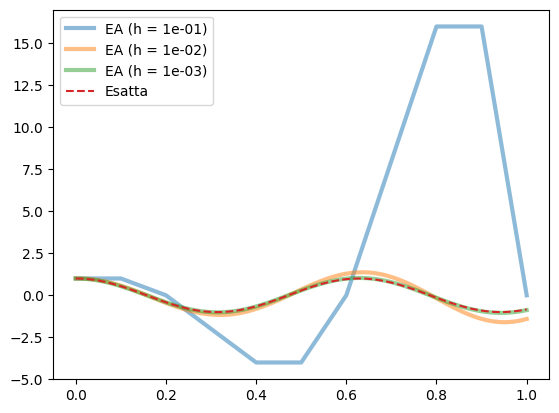

In [6]:
import matplotlib.pyplot as plt

plt.figure()

# Confronto le soluzioni numeriche al variare di h
for h in [1e-1, 1e-2, 1e-3]:
    t_h, u_h= eulero_avanti(f, t0, t_max, [x0,v0], h)
    plt.plot(t_h, u_h[0,:], "-", alpha=0.5, label="EA (h = %.0e)" % h, linewidth=3)
    #u_h[0,:] per estrarre solo la prima riga che indica la posizione, perché la seconda è la velocità e io voglio plottare solo lo spostamento
# Rappresento la soluzione esatta
tt = np.linspace(t0, t_max, 100)

plt.plot(tt, u_ex(tt), "--", label="Esatta")
plt.legend()
plt.show()
#dal plot vediamo che con h=0.001 il metodo converge alla sol esata

<mark>**Esercizio 1.3**</mark></br>

Si discuta l'assoluta stabilità del metodo di Eulero esplicito per questo problema. Si verifichi poi il comportamento della soluzione numerica per $t_{\text{max}} = 100$ e $h=0.001$.

**Remark:** nel caso vettoriale, l'assoluta stabilità di un metodo numerico si studia con riferimento al seguente problema modello generalizzato:

$$
\begin{cases}
\mathbf{y}'(t) = J \mathbf{y}(t) \\
\mathbf{y}(t) = \mathbf{y}_0
\end{cases}
$$

dove, $J$ è una matrice data (per semplicità assumiamo che $J$ non dipenda dal tempo). Nel caso in cui $J$ ammette $n$ autovalori distinti $\lambda_i \in \mathbb{C}$, la condizione di assoluta stabilità per il metodo di Eulero esplicito risulta una generalizzazione di quella vista nel caso scalare:

$$
|1+\lambda_i h| < 1 \quad \forall i = 1,...,n
$$

In [7]:
from scipy.linalg import eigvals
# Definisco J (osservo che non dipende dal tempo)
J= np.array([[0,1],
            [-k/m, 0]])
# Calcolo gli autovalori di J
eigvals(J)

array([0.+10.j, 0.-10.j])

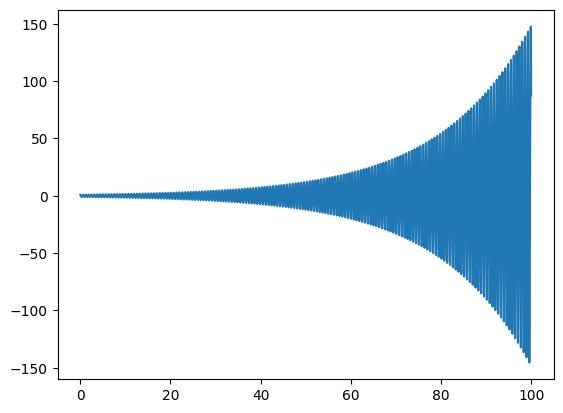

In [ ]:
# Verifico come si comporta la soluzione per tempi lunghi
t_h, u_h =eulero_avanti(f, t0, 100, [x0,v0], 1e-3)
plt.plot(t_h, u_h[0,:])
#osservo che il metodo è instabile perché ci sono oscillazioni che divergono per tempi lunghi

<mark>**Esercizio 1.4**</mark></br>

Si risolva il problema differenziale con il metodo di Eulero implicito. A tale scopo, si utilizzi la funzione `eulero_indietro` che è stata opportunamente modificata in modo da gestire correttamente anche il caso vettoriale, sotto l'ipotesi che $\mathbf{f}$ sia rappresentabile attraverso una matrice, come $\mathbf{f} = A \mathbf{y}$ (ovvero, consideriamo solo il caso di **ODE lineari**, mentre non vediamo a laboratorio il caso di ODE non lineari, per il quale però `eulero_indietro` si potrebbe tranquillamente generalizzare).

Si approssimi la soluzione per $t_0 = 0$, $t_\text{max} = 1$, $m=1$, $k=100$, $v_0=0$, $x_0=1$, $\gamma= 0$, $f_0=0$. Si confronti graficamente la soluzione esatta $x(t) = \cos(10t)$ con quella ottenuta ponendo $h=0.001$, $h= 0.01$ e $h=0.1$. Si commentino i risultati.

In [8]:
from utilis_ODE import eulero_indietro

help(eulero_indietro)

Help on function eulero_indietro in module utilis_ODE:

eulero_indietro(f, t0, tN, y0, h, nmax_pf=300, toll_pf=1e-05)
    Metodo di Eulero all'indietro (Backward Euler).

    Risolve il problema ai valori iniziali:
        y'(t) = f(t, y(t)),  t ∈ [t0, tN]
        y(t0) = y0

    utilizzando lo schema implicito:
        y_{n+1} = y_n + h*f(t_{n+1}, y_{n+1})

    Per problemi scalari, utilizza il metodo del punto fisso per risolvere l'equazione implicita.
    Per sistemi lineari, utilizza la fattorizzazione LU.

    Input:
        f (callable o numpy.ndarray): Termine di destra dell'ODE se scalare,
                                     o matrice A se vettoriale (per sistemi lineari)
        t0 (float): Tempo iniziale
        tN (float): Tempo finale
        y0 (float, list o numpy.ndarray): Dato iniziale (scalare o vettore)
        h (float): Passo temporale
        nmax_pf (int): Numero massimo di iterazioni per il punto fisso (default: 300)
        toll_pf (float): Tolleranza per il cr

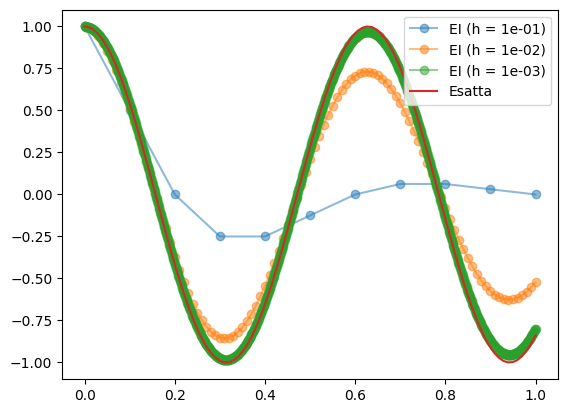

In [9]:
# Dati del problema
t0 = 0
t_max = 1
x0 = 1
v0 = 0
m = 1
k = 100
gamma = 0

# Soluzione esatta
u_ex = lambda t: np.cos(10 * t)

# Risolvo il sistema al variare di h
for h in [1e-1, 1e-2, 1e-3]:
    t_h, u_h=eulero_indietro(J, t0, t_max, [x0,v0], h)
    plt.plot(t_h, u_h[0,:], "-o", alpha=0.5, label="EI (h = %.0e)" % h)

tt = np.linspace(t0, t_max, 100)
plt.plot(tt, u_ex(tt), label="Esatta")

plt.legend()
plt.show()

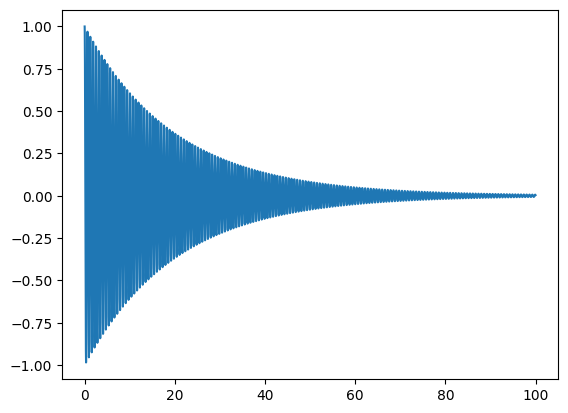

In [ ]:
#verifico come si comporta la soluzione per tempi lunghi
t_h, u_h=eulero_indietro(J, t0, 100, [x0, v0], 1e-3)
plt.plot(t_h, u_h[0,:])

#osserviamo che le soluzione converge ma non a quella esatta, 
#c'è dissipazione di energia e quindi converge a zero, sto quindi introducendo uno smorzamento con il metodo numerico che dal punto di vista fisico non c'è


## Metodi di alto ordine per ODE

I metodi numerici utilizzati per risolvere il generico problema di Cauchy:

$$
\begin{cases}
y'(t) = f(t,y), \quad t_0<t\leq t_{\max}, \\
y(t_0) = y_0,
\end{cases}
$$

si basano sulla seguente strategia:

1. Stabilire un passo di avanzamento temporale $h$,

2. Suddividere l'intervallo temporale $[t_0,t_{\max}]$ in un numero $N_h$ di sottointervalli
$$ N_h = \frac{t_{\max}-t_0}{h} $$
di eguale ampiezza $h$,

3. Per ogni istante temporale discreto $t_n$, con $t_0 < t_n < t_{\max}$, si calcola il valore incognito $u_n$ che approssima la soluzione $y_n=y(t_n)$.

L'insieme dei valori $\{u_0 = y_0, \ u_1,\dots,u_{N_h}\}$ rappresenta la soluzione numerica del problema di Cauchy.

Nel Lab 7 sono stati introdotti i metodi di *Eulero avanti*, *Eulero indietro* e *Crank-Nicolson*. In questo Laboratorio vogliamo però indagare metodi che garantiscano un ordine di convergenza superiore. Esistono due famiglie di metodi a tal proposito:

*   **Metodi di Runge-Kutta**, che per calcolare $u_{n+1}$ sfruttano più stadi costruendo la soluzione in modo nonlineare.
*   **Metodi multistep**, che per calcolare $u_{n+1}$ sfruttano non solo $u_n$, ma anche la soluzione numerica calcolata in istanti precedenti.

In particolare, ci occupiamo della prima famiglia.

## Metodi di Runge-Kutta (RK)

I metodi di Runge-Kutta sono dei metodi **a un passo**, ma rispetto a Eulero in avanti consentono di raggiungere un ordine di accuratezza più elevato. Ad ogni passo, la soluzione numerica è calcolata secondo la seguente formula:

$$
u_{n+1} = u_{n} + h F(t_n, u_n, h; f)
$$

Ad esempio, il metodo di Runge-Kutta esplicito a due stadi, anche noto come **metodo di Heun**, risulta:

$$
\begin{cases}
u_* = u_{n} + h f(t_n, u_n) \\
u_{n+1} = u_{n} + \frac{h}{2} \left(f(t_n, u_n) + f(t_{n+1}, u_*) \right)
\end{cases}
$$

Oppure, in generale, un metodo di Runge-Kutta a *s* stadi può essere scritto come:

$$
F(t_n, u_n, h; f) = \sum_{i=1}^s b_i K_i
$$

$$
K_i = f \left(t_n + c_i h ~,~ u_n + \sum_{j=1}^s a_{ij} K_j \right)  \quad\quad i = 1,...,s
$$

## Esercizio 2

Si consideri il problema di Cauchy

$$
\begin{cases}
y'(t) = -ty(t), \quad t_0<t\leq t_{\max}, \\
y(t_0) = 1,
\end{cases}
$$

con $t_0 = 0$ e $t_\text{max} = 5$, la cui soluzione esatta è data da: $y(t) = e^{- \frac{t^2}{2} }$

<mark>**Esercizio 2.1**</mark></br>

Si risolva il problema di Cauchy con il metodo di Eulero in avanti, sfruttando lo script `utilis_ODE.py`, con passo $h=0.01$ e si calcoli l'errore assoluto

$$
e_h = \max_{n=1,\dots,N_h} |y(t_n)-u_n|.
$$

In [2]:
import numpy as np
from utilis_ODE import eulero_avanti

# Dati del problema
f=lambda t, y: -t*y
t0=0
t_max=5
y0=1

#Soluzione esatta
y_ex=lambda t: np.exp(-(t**2)/2)

# Risolvo il problema di Cauchy
t_EA, y_EA= eulero_avanti(f, t0, t_max, y0, 0.01)


In [ ]:
y_EA.shape
#vediamo che è un vettore da 502 componenti, non una matrice

(501,)

In [3]:
# Calcolo l'errore
err_EA=np.max(np.abs(y_EA-y_ex(t_EA)))
nstepsEA=len(t_EA)-1

print("Errore globale EA:\t%.2e" % err_EA)
print("Passi effettuati:\t%d" % nstepsEA)


Errore globale EA:	2.31e-03
Passi effettuati:	500


<mark>**Esercizio 2.2**</mark></br>

Si risolva ora il problema con il metodo di Runge-Kutta a 3 stadi (s=3). Ad esempio, una delle possibili formulazioni è la seguente:

$$
\begin{cases}
u_0 = y_0 \\
u_{n+1} = u_n + \frac{h}{6} (K_1 + 4 K_2 + K_3) \quad\quad n=0,...,N_h
\end{cases}
$$

dove,
$$
\begin{aligned}
K_1 & = f(t_n, u_n) \\
K_2 & = f(t_n + \frac{1}{2} h , u_n + \frac{1}{2} h K_1) \\
K_3 & = f(t_n + h, u_n - hK_1 + 2hK_2)
\end{aligned}
$$

A tal proposito, si sfrutti la function `RK23` della libreria Python `scipy.integrate` (fissando tolleranza relativa ed assoluta a $10^{-8}$ in `RK23`).
Si calcoli poi l'errore assoluto.

In [4]:
from scipy.integrate import RK23
#il num 3 dice che è un metodo a 3 stadi, mentre il num 2 dice che si usa un metodo di ordine 2 per adattività di passo
#il primo numero è sempre un ordine inferiore al numero di stadi

*NB: RK23 implementa una variante del metodo di Runge-Kutta descritto sopra. Nello specifico, RK23 consiste in un metodo adattivo basato su due metodi di Runge-Kutta: uno di ordine 3 (per effettuare il passo) ed uno di ordine 2 (per scegliere, ad ogni step, il nuovo passo temporale $h^n$). Inoltre, diversamente dalle implementazioni che abbiamo visto finora, questa function non simula direttamente tutta la traiettoria. RK23 è una classe! Chiamando RK23 ci viene restituito un oggetto che può essere evoluto in tempo chiamando il metodo `.step()`. In sostanza, RK23 implementa l'iteratore dello schema numerico.*

*In ogni momento potete accedere agli attributi `.t`
 e `.y` dell'iteratore per conoscere, rispettivamente, il tempo corrente $t^n$ e lo stato corrente del sistema, $y^n$.*

**Approfondimento**: per chi volesse approfondire il concetto di *classe* può trovare su internet numerosi riferimenti. Qui è presente una breve spiegazione: https://aulab.it/guide-avanzate/classi-e-oggetti-in-python

In [19]:
# Costruisco un oggetto della classe RK23
rk23=RK23(f, t0, [y0], t_max) #per come è stata implementata la funzione dobbiamo dare il dato iniziale y0 come array quindi per questo sta tra []

# Esempio: chiamo gli attributi t e y della classe
rk23.t 
rk23.y


array([1.])

In [20]:
t_RK23=[t0]
y_RK23=[[y0]] #lista di lista, quindi metto y0 come array

# Risolvo
while rk23.t<t_max:
    rk23.step() #ad ogni iterazione avanzo con il metodo step
    t_RK23.append(rk23.t)
    y_RK23.append(rk23.y)

t_RK23=np.array(t_RK23)
y_RK23= np.stack(y_RK23)


In [21]:
y_RK23.shape

(27, 1)

In [22]:
# Calcolo l'errore
err_RK23 = np.max(np.abs(y_RK23[:, 0] - y_ex(t_RK23)))
nstepsRK23 = len(t_RK23) - 1.0
print("Errore globale RK23:\t%.2e" % err_RK23)
print("Passi effettuati:\t%d" % nstepsRK23)

Errore globale RK23:	1.22e-03
Passi effettuati:	26


<mark>**Esercizio 2.3**</mark></br>

Si confrontino il metodo EA con RK23, analizzando l'errore commesso nei due casi e il numero di istanti temporali utilizzati.

In [23]:
print("Errore globale EA:\t%.2e" % err_EA)
print("Passi effettuati:\t%d" % nstepsEA)

print("Errore globale RK23:\t%.2e" % err_RK23)
print("Passi effettuati:\t%d" % nstepsRK23)

Errore globale EA:	2.31e-03
Passi effettuati:	500
Errore globale RK23:	1.22e-03
Passi effettuati:	26


<mark>**Esercizio 2.4**</mark></br>

Si ripeta l'Esercizio 2.2 utilizzando un metodo di Runge-Kutta di ordine superiore, implementato nella function `RK45`,
 della libreria Python `scipy.integrate` e si calcoli l'errore assoluto. Cosa si può concludere?


In [13]:
from scipy.integrate import RK45
rk45=RK45(f, t0, [y0], t_max)
t_RK45=[t0]
y_RK45=[[y0]]

while rk45.t < t_max:
    rk45.step()
    t_RK45.append(rk45.t)
    y_RK45.append(rk45.y)
t_RK45=np.array(t_RK45)
y_RK45=np.stack(y_RK45)

err_RK45 = np.max(np.abs(y_RK45[:, 0] - y_ex(t_RK45)))
nstepsRK45 = len(t_RK45) - 1.0

print("Errore globale RK45:\t%.2e" % err_RK45)
print("Passi effettuati:\t%d" % nstepsRK45)

Errore globale RK45:	1.92e-04
Passi effettuati:	16


<mark>**Esercizio 2.5**</mark></br>

Confrontate graficamente soluzione esatta e approssimazioni numeriche (utilizzate quelle ottenute ai punti 2.1, 2.2 ed 2.4).



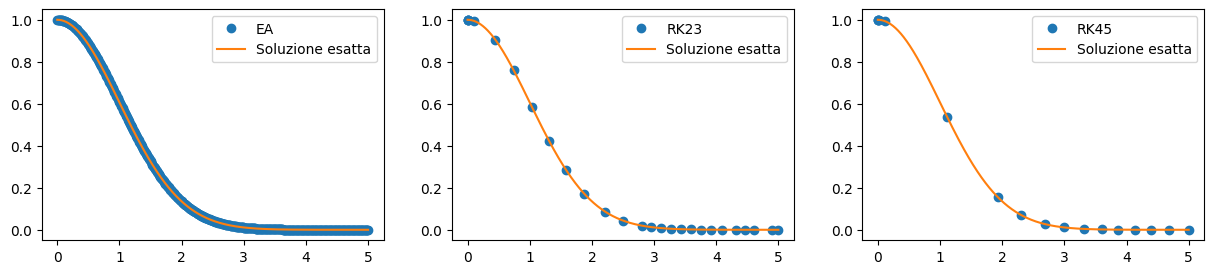

In [24]:
import matplotlib.pyplot as plt

t_plot = np.linspace(t0, t_max, 1000)
plt.figure(figsize=(15, 3))
plt.subplot(1, 3, 1)
plt.plot(t_EA, y_EA, "o", label="EA")
plt.plot(t_plot, y_ex(t_plot), label="Soluzione esatta")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(t_RK23, y_RK23[:, 0], "o", label="RK23")
plt.plot(t_plot, y_ex(t_plot), label="Soluzione esatta")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(t_RK45, y_RK45[:, 0], "o", label="RK45")
plt.plot(t_plot, y_ex(t_plot), label="Soluzione esatta")
plt.legend()

plt.show()

**Remark**: qui abbiamo sfruttato l'implementazione di `scipy.integrate.RK`, che consentiva l'adattività, però attenzione a non confondere i metodi di Runge-Kutta con l'adattività. Sono due aspetti separati!

## Esercizi per casa

Si consideri nuovamente il problema dell'Esercizio 1, che descrive un oscillatore armonico smorzato e forzato:

$$
\begin{cases}
m \ddot x = -kx - \gamma\dot x + f_0 \cos(\Omega t), \quad t_0<t\leq t_{\max}, \\
\dot x(t_0) = v_0, \\
x(t_0) = x_0,
\end{cases}
$$

dove $m$ è la massa dell'oggetto attaccato alla molla, $k$ la costante elastica della molla, $\gamma$ il coefficiente di smorzamento e $f_0\cos(\Omega t)$ è un termine forzante di ampiezza $f_0$ e frequenza $\Omega$.
La pulsazione dell'oscillazione è definita come

$$
\omega = \sqrt{\dfrac{k}{m}}.
$$

<mark>**Esercizio 3.1**</mark></br>

Si ponga $t_0 = 0$, $t_{\max} = 10$, $m=1$, $k=4$, $v_0=1$, $x_0=0$.

Mediante la funzione RK45 di Python si sperimentino i seguenti casi, visualizzandone la soluzione numerica e discutendo i risultati ottenuti alla luce dei risultati teorici.

1. **Oscillatore armonico semplice**: $\gamma = f_0 = 0$.
La soluzione esatta è

$$
x(t) = A\cos(\omega t+\theta_0),
$$
dove
$$
A = -\dfrac{v_0}{\sin(\theta_0)\omega}, \quad \theta_0 = \arctan\left( \dfrac{v_0}{\omega x_0} \right).
$$</br>

2. **Oscillatore armonico sovra-smorzato**: $f_0 = 0$, $\gamma^2 >4mk$. Si assuma $\gamma=5$.
La soluzione esatta è

$$
x(t) = c_0 e^{\lambda_0 t} + c_1 e^{\lambda_1 t},
$$
dove
$$
\lambda_{k}=\frac{-\gamma+(-1)^{k}\sqrt{\gamma^{2}-4mk}}{2m},\quad\quad c_{0}=x_{0}-c_{1},\quad\quad c_{1}=\frac{v_{0}-x_{0}\lambda_{0}}{\lambda_{1}-\lambda_{0}}
$$

3. **Oscillatore armonico sotto-smorzato**: $f_0 = 0$, $\gamma^2 < 4mk$. Si assuma $\gamma = 1$.
La soluzione esatta è
$$
x(t) = e^{-\frac{\gamma}{2m}t}\left(A\cos(\omega_1 t)+B\sin(\omega_1 t)\right),
$$</br>
dove
$$
\omega_1 = \dfrac{\sqrt{4mk-\gamma}}{2m}, \quad A=x_0, \quad B=\dfrac{v_0}{\omega_1} + \dfrac{\gamma x_0}{2m\omega_1}.
$$

4. **Oscillatore armonico forzato**: $\gamma=1$, $f_0=1$, $\Omega=0.5$. In questo caso si ponga $t_{\max}=30$.

In [26]:
#funzione per applicare Runge Kutta 45
def RungeKutta45(f, t0, y0, t_max, rtol, atol):
    """Metodo di Runge-Kutta 45
    Input:
    f (lambda function) termine noto dell'ODE di primo ordine
    t0 (float) tempo iniziale
    t_max (float) tempo finale
    y0 (numpy.ndarray) dato iniziale (vettore d-dimensionale)
    rtol (float) tolleranza relativa per RK45
    atol (float) tolleranza assoluta per RK45
    Output:
    t_h (numpy.ndarray) array degli istanti temporali discreti
    u_h (numpy.ndarray) soluzione discreta, salvata in un array␣
    ↪len(t_h) x d
    """

    integratore = RK45(f, t0, y0, t_max, rtol=rtol, atol=atol)
    t_h = [t0]
    u_h = [y0]
    while integratore.t < t_max:
        integratore.step()
        t_h.append(integratore.t)
        u_h.append(integratore.y)
    return np.array(t_h), np.stack(u_h)

#funzione per scrivere il termine di destra
def get_f(k, m, gamma, f0, Omega):
    f = lambda t, y: [
         y[1],
        -k / m * y[0] - gamma / m * y[1] + f0 / m * np.cos(Omega * t),
    ]
    return f

In [28]:
#dati iniziali comuni
t0, t_max =0, 10
m=1
k=4
v0, x0 = 1, 0

Omega=0


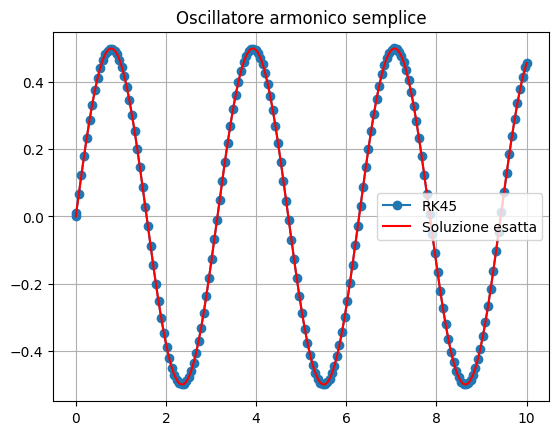

In [39]:
#Caso 1: oscillatore armonico semplice
f1=get_f(k,m,0, 0, Omega)
t_h1, u_h1=RungeKutta45(f1, t0, [x0,v0], t_max, 1e-8, 1e-8)

pulsaz=np.sqrt(k/m)
theta0=np.pi/2
A=-v0/(np.sin(theta0)*pulsaz)
y_ex=lambda t: A*np.cos(pulsaz*t+theta0)

plt.figure()
plt.plot(t_h1, u_h1 [:,0], '-o', label='RK45')
tt=np.linspace(t0, t_max, 1000)
plt.plot(tt, y_ex(tt), label='Soluzione esatta', color='red')
plt.grid()
plt.legend()
plt.title('Oscillatore armonico semplice')
plt.show()

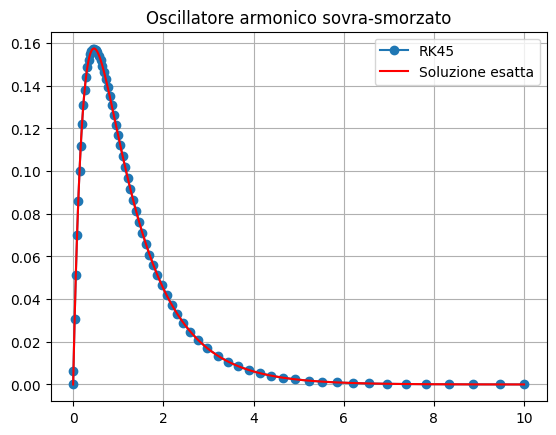

In [40]:
#Caso 2: oscillatore armonico sovra-smorzato
gamma=5
f0=0
f2=get_f(k,m, gamma, f0, Omega)
t_h2, u_h2=RungeKutta45(f2, t0, [x0,v0], t_max, 1e-8, 1e-8)

pulsaz=np.sqrt(k/m)
lambda0=(-gamma+np.sqrt(gamma**2-4*m*k))/(2*m)
lambda1=(-gamma-np.sqrt(gamma**2-4*m*k))/(2*m)
c1=(v0-x0*lambda0)/(lambda1-lambda0)
c0=x0-c1
y_ex=lambda t: c0*np.exp(lambda0*t)+c1*np.exp(lambda1*t)

plt.figure()
plt.plot(t_h2, u_h2 [:,0], '-o', label='RK45')
tt=np.linspace(t0, t_max, 1000)
plt.plot(tt, y_ex(tt), label='Soluzione esatta', color='red')
plt.grid()
plt.legend()
plt.title('Oscillatore armonico sovra-smorzato')
plt.show()


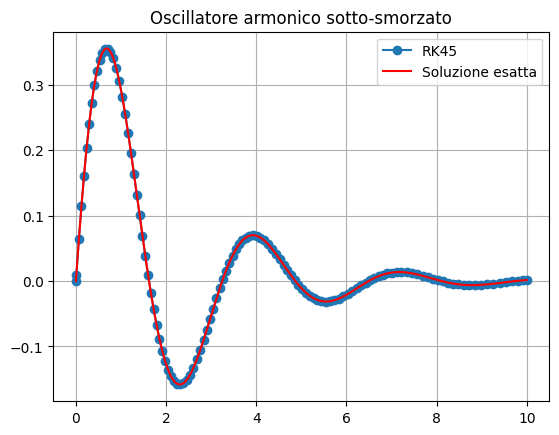

In [41]:
#Caso 3: oscillatore armonico sotto-smorzato
gamma=1
f0=0
f3=get_f(k,m, gamma, f0, Omega)
t_h3, u_h3=RungeKutta45(f3, t0, [x0,v0], t_max, 1e-8, 1e-8)

pulsaz1=np.sqrt(4*m*k-gamma)/(2*m)
A=x0
B=v0/pulsaz1+gamma*x0/(2*m*pulsaz1)
y_ex=lambda t: np.exp(-gamma/(2*m)*t)*(A*np.cos(pulsaz1*t)+B*np.sin(pulsaz1*t))
plt.figure()
plt.plot(t_h3, u_h3 [:,0], '-o', label='RK45')
tt=np.linspace(t0, t_max, 1000)
plt.plot(tt, y_ex(tt), label='Soluzione esatta', color='red')
plt.grid()
plt.legend()
plt.title('Oscillatore armonico sotto-smorzato')
plt.show()


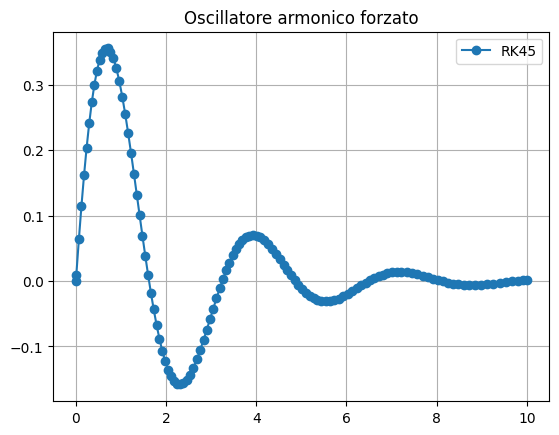

In [42]:
#Caso 4:oscillatore armonico forzato
gamma=1
f0=1
Omega=0.5
t_max=30
f4=get_f(k,m, gamma, f0, Omega)
t_h4, u_h4=RungeKutta45(f4, t0, [x0,v0], t_max, 1e-8, 1e-8)


plt.figure()
plt.plot(t_h3, u_h3 [:,0], '-o', label='RK45')
plt.grid()
plt.legend()
plt.title('Oscillatore armonico forzato')
plt.show()

<mark>**Esercizio 3.2**</mark></br>

Confrontare le soluzioni numeriche ottenute nell'Esercizio 3.1, rappresentandole nel piano delle fasi, cioè nel piano posizione-velocità, $(x,\dot{x})$.

In [43]:
soluzione = dict()
soluzione["semplice"] = u_h1
soluzione["sovra-smorzato"] = u_h2
soluzione["sotto-smorzato"] = u_h3
soluzione["forzato"] = u_h4

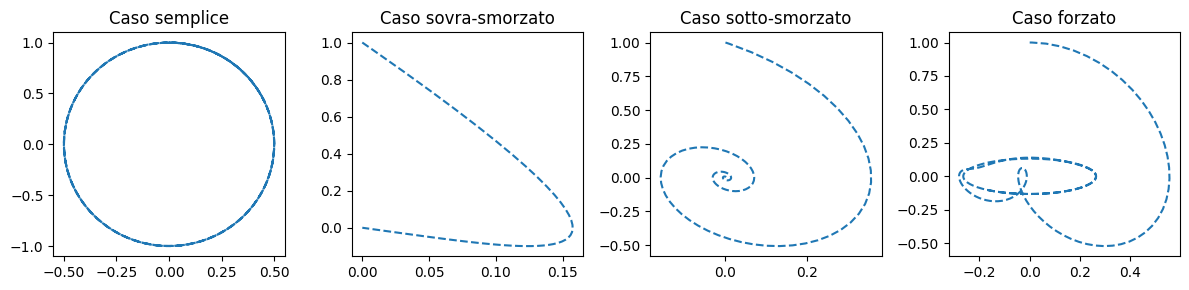

In [45]:
plt.figure(figsize=(12, 3))
casi = soluzione.keys()

for i, caso in enumerate(casi):
    plt.subplot(1, 4, i + 1)
    x = soluzione[caso][:, 0]
    v = soluzione[caso][:, 1]
    plt.plot(x, v, "--")
    plt.title("Caso %s" % caso)

plt.tight_layout()
plt.show()


**Extra**: tramite lo script `spring.py` è possibile visualizzare delle animazioni che mostrano visivamente il comportamento dell'oscillatore nei quattro casi considerati!